# Grad-CAM Visualization on Video Frames

This notebook overlays Grad-CAM heatmaps on original video frames to visualize which body regions are important for exercise classification.

**Prerequisites:** Run `training.ipynb` first to train and save the model.

In [19]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import cv2
from scipy.ndimage import zoom

import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
# Configuration
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
SKELETON_DIR = DATA_DIR / "dataset" / "skeleton" / "yolo_pose_csv"
VIDEO_DIR = DATA_DIR / "dataset" / "anon"
LABEL_DIR = DATA_DIR / "label"
SPLIT_FILE = DATA_DIR / "split.csv"
OUTPUT_DIR = BASE_DIR / "output"
MODEL_PATH = OUTPUT_DIR / "action_3dcnn_model.pth"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")

Using device: cuda
Model path: /net/afscra/people/plgmateuszoracz/wk/project/output/action_3dcnn_model.pth
Model exists: True


## 1. Load Model

In [21]:
class Action3DCNN(nn.Module):
    """3D-CNN for skeleton-based action recognition."""

    def __init__(self, num_classes, sequence_length=64, num_keypoints=17,
                 hidden_channels=None, dropout=0.3):
        super().__init__()
        if hidden_channels is None:
            hidden_channels = [32, 64, 128]

        self.num_classes = num_classes
        self.sequence_length = sequence_length
        self.num_keypoints = num_keypoints

        self.conv_layers = nn.ModuleList()

        in_ch = 3
        for out_ch in hidden_channels:
            self.conv_layers.append(
                nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                    nn.MaxPool2d(kernel_size=2, stride=2)
                )
            )
            in_ch = out_ch

        self._calc_flat_size(sequence_length, num_keypoints)

        self.fc = nn.Sequential(
            nn.Linear(self.flat_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

        self.gradients = None
        self.activations = None

    def _calc_flat_size(self, T, K):
        h, w = T, K
        for _ in self.conv_layers:
            h = h // 2
            w = max(w // 2, 1)
        self.flat_size = self.conv_layers[-1][0].out_channels * h * w

    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        for i, conv_block in enumerate(self.conv_layers):
            x = conv_block(x)
            if i == len(self.conv_layers) - 1:
                self.activations = x
                if x.requires_grad:
                    x.register_hook(self.activations_hook)

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [22]:
# Load checkpoint
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)

CONFIG = checkpoint['config']
num_classes = checkpoint['num_classes']
label_to_idx = checkpoint['label_to_idx']
idx_to_label = checkpoint['idx_to_label']

print(f"Loaded model with {num_classes} classes")
print(f"Test accuracy: {checkpoint['test_acc']:.2f}%")
print(f"\nLabel mapping:")
for idx, label in idx_to_label.items():
    print(f"  {idx}: Exercise {label}")

# Create and load model
model = Action3DCNN(
    num_classes=num_classes,
    sequence_length=CONFIG['sequence_length'],
    num_keypoints=CONFIG['num_keypoints'],
    hidden_channels=CONFIG['hidden_channels'],
    dropout=CONFIG['dropout']
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("\nModel loaded successfully!")

Loaded model with 16 classes
Test accuracy: 91.74%

Label mapping:
  0: Exercise 1
  1: Exercise 2
  2: Exercise 3
  3: Exercise 4
  4: Exercise 5
  5: Exercise 6
  6: Exercise 7
  7: Exercise 8
  8: Exercise 9
  9: Exercise 10
  10: Exercise 11
  11: Exercise 12
  12: Exercise 13
  13: Exercise 14
  14: Exercise 15
  15: Exercise 16

Model loaded successfully!


## 2. Grad-CAM Implementation

In [23]:
class GradCAM:
    """Grad-CAM implementation for 3D-CNN action recognition model."""
    
    def __init__(self, model, target_layer_idx=-1):
        self.model = model
        self.target_layer_idx = target_layer_idx
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()
    
    def _register_hooks(self):
        target_layer = self.model.conv_layers[self.target_layer_idx]
        
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        self.hook_handles.append(target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(target_layer.register_full_backward_hook(backward_hook))
    
    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()
    
    def generate_cam(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)
        
        output = self.model(input_tensor)
        pred_probs = torch.softmax(output, dim=1)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        pred_prob = pred_probs[0, target_class].item()
        
        self.model.zero_grad()
        target = output[0, target_class]
        target.backward()
        
        gradients = self.gradients
        activations = self.activations
        
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        
        cam = cam.squeeze()
        if cam.max() > 0:
            cam = cam / cam.max()
        
        cam = cam.cpu().numpy()
        cam_resized = self._resize_cam(cam, (input_tensor.shape[2], input_tensor.shape[3]))
        
        return cam_resized, target_class, pred_prob
    
    def _resize_cam(self, cam, target_size):
        h_ratio = target_size[0] / cam.shape[0]
        w_ratio = target_size[1] / cam.shape[1]
        cam_resized = zoom(cam, (h_ratio, w_ratio), order=1)
        return cam_resized

## 3. Data Loading Functions

In [24]:
def load_skeleton_file(filepath):
    """Load skeleton CSV file."""
    df = pd.read_csv(filepath)

    # Rename columns if needed
    if 'frame_number' not in df.columns:
        df.columns = ['frame_number', 'landmark', 'x', 'y', 'z']

    landmarks_order = df[df['frame_number'] == df['frame_number'].min()]['landmark'].tolist()
    num_keypoints = len(landmarks_order)
    frames = sorted(df['frame_number'].unique())
    num_frames = len(frames)
    
    skeleton_array = np.zeros((num_frames, num_keypoints, 3), dtype=np.float32)
    
    for frame_idx, frame_num in enumerate(frames):
        frame_data = df[df['frame_number'] == frame_num]
        for kp_idx, landmark in enumerate(landmarks_order):
            kp_data = frame_data[frame_data['landmark'] == landmark]
            if len(kp_data) > 0:
                skeleton_array[frame_idx, kp_idx, 0] = kp_data['x'].values[0]
                skeleton_array[frame_idx, kp_idx, 1] = kp_data['y'].values[0]
                skeleton_array[frame_idx, kp_idx, 2] = kp_data['z'].values[0]
    
    return skeleton_array, landmarks_order


def load_label_file(filepath):
    """Load label CSV file."""
    df = pd.read_csv(filepath, header=None, names=['frame', 'col1', 'label'])
    return df['label'].values

## 4. Video Grad-CAM Visualization Functions

In [25]:
def get_video_frames(video_path, start_frame, num_frames):
    """Extract frames from video."""
    cap = cv2.VideoCapture(str(video_path))
    frames = []
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    
    for _ in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    
    cap.release()
    return frames


def create_skeleton_heatmap(cam_frame, keypoint_coords, frame_shape, sigma=30):
    """Create heatmap based on keypoint importance."""
    h, w = frame_shape[:2]
    heatmap = np.zeros((h, w), dtype=np.float32)
    
    y_grid, x_grid = np.ogrid[:h, :w]
    
    for kp_idx, importance in enumerate(cam_frame):
        if importance < 0.01:
            continue
            
        kp_x = int(keypoint_coords[0, kp_idx] * w)
        kp_y = int(keypoint_coords[1, kp_idx] * h)
        
        kp_x = max(0, min(w-1, kp_x))
        kp_y = max(0, min(h-1, kp_y))
        
        gaussian = np.exp(-((x_grid - kp_x)**2 + (y_grid - kp_y)**2) / (2 * sigma**2))
        heatmap += importance * gaussian
    
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()
    
    return heatmap


def overlay_heatmap_on_frame(frame, heatmap, alpha=0.4):
    """Overlay heatmap on video frame."""
    heatmap_uint8 = (heatmap * 255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    frame_overlay = cv2.addWeighted(frame, 1 - alpha, heatmap_color, alpha, 0)
    return frame_overlay


def draw_skeleton_on_frame(frame, keypoint_coords, importance=None):
    """Draw skeleton with keypoints on frame."""
    h, w = frame.shape[:2]
    frame_copy = frame.copy()
    
    # Skeleton connections
    connections = [
        (0, 1), (0, 2), (1, 3), (2, 4),  # Head
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),  # Arms
        (5, 11), (6, 12), (11, 12),  # Torso
        (11, 13), (13, 15), (12, 14), (14, 16)  # Legs
    ]
    
    # Draw connections
    for i, j in connections:
        pt1 = (int(keypoint_coords[0, i] * w), int(keypoint_coords[1, i] * h))
        pt2 = (int(keypoint_coords[0, j] * w), int(keypoint_coords[1, j] * h))
        cv2.line(frame_copy, pt1, pt2, (200, 200, 200), 2)
    
    # Draw keypoints
    for kp_idx in range(keypoint_coords.shape[1]):
        pt = (int(keypoint_coords[0, kp_idx] * w), int(keypoint_coords[1, kp_idx] * h))
        
        if importance is not None:
            # Color based on importance (blue -> red)
            imp = importance[kp_idx]
            color = (int(255 * (1 - imp)), 0, int(255 * imp))  # BGR
            radius = int(5 + 10 * imp)
        else:
            color = (0, 255, 0)
            radius = 5
        
        cv2.circle(frame_copy, pt, radius, color, -1)
    
    return frame_copy

In [26]:
def visualize_gradcam_on_video(video_path, skeleton_data, cam, start_frame,
                                pred_class, true_class, pred_prob, idx_to_label,
                                num_frames_to_show=8, save_path=None):
    """Visualize Grad-CAM heatmap overlaid on video frames."""
    sequence_length = cam.shape[0]
    
    frames = get_video_frames(video_path, start_frame, sequence_length)
    
    if len(frames) == 0:
        print(f"Could not read frames from {video_path}")
        return None
    
    frame_indices = np.linspace(0, min(len(frames)-1, sequence_length-1), 
                                 num_frames_to_show, dtype=int)
    
    fig, axes = plt.subplots(3, num_frames_to_show, figsize=(3*num_frames_to_show, 9))
    
    for col, frame_idx in enumerate(frame_indices):
        if frame_idx >= len(frames):
            continue
            
        frame = frames[frame_idx]
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        keypoint_coords = skeleton_data[:2, frame_idx, :]
        cam_frame = cam[frame_idx, :]
        
        heatmap = create_skeleton_heatmap(cam_frame, keypoint_coords, frame.shape)
        frame_overlay = overlay_heatmap_on_frame(frame, heatmap, alpha=0.5)
        frame_overlay_rgb = cv2.cvtColor(frame_overlay, cv2.COLOR_BGR2RGB)
        
        frame_skeleton = draw_skeleton_on_frame(frame, keypoint_coords, cam_frame)
        frame_skeleton_rgb = cv2.cvtColor(frame_skeleton, cv2.COLOR_BGR2RGB)
        
        # Row 1: Original frame
        axes[0, col].imshow(frame_rgb)
        axes[0, col].set_title(f'Frame {start_frame + frame_idx}', fontsize=9)
        axes[0, col].axis('off')
        
        # Row 2: Skeleton with importance
        axes[1, col].imshow(frame_skeleton_rgb)
        axes[1, col].axis('off')
        
        # Row 3: Heatmap overlay
        axes[2, col].imshow(frame_overlay_rgb)
        axes[2, col].axis('off')
    
    axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, ha='right', va='center')
    axes[1, 0].set_ylabel('Skeleton', fontsize=10, rotation=0, ha='right', va='center')
    axes[2, 0].set_ylabel('Grad-CAM', fontsize=10, rotation=0, ha='right', va='center')
    
    correct_str = '✓' if pred_class == true_class else '✗'
    fig.suptitle(f'Grad-CAM on Video Frames\n'
                 f'Predicted: Exercise {idx_to_label[pred_class]} ({pred_prob:.1%}) | '
                 f'True: Exercise {idx_to_label[true_class]} {correct_str}',
                 fontsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()
    return fig

## 5. Generate Video Grad-CAM Visualizations

In [27]:
# Load test files from split.csv
split_df = pd.read_csv(SPLIT_FILE, header=None, names=['file_name', 'split'])
test_files = set(split_df[split_df['split'] == 'test']['file_name'].tolist())

print(f"Test files: {len(test_files)}")

# Find test samples with matching video files
test_samples_with_video = []

for file_name in tqdm(test_files, desc="Finding samples"):
    skeleton_path = SKELETON_DIR / f"{file_name}.csv"
    video_path = VIDEO_DIR / f"{file_name}.mp4"
    label_path = LABEL_DIR / f"{file_name}.csv"
    
    if not skeleton_path.exists() or not video_path.exists() or not label_path.exists():
        continue
    
    try:
        skeleton_data, _ = load_skeleton_file(skeleton_path)
        labels = load_label_file(label_path)
        
        min_len = min(len(skeleton_data), len(labels))
        skeleton_data = skeleton_data[:min_len]
        labels = labels[:min_len]
        
        seq_len = CONFIG['sequence_length']
        stride = CONFIG['stride']
        
        for start_idx in range(0, len(skeleton_data) - seq_len + 1, stride):
            seq_data = skeleton_data[start_idx:start_idx + seq_len]
            seq_labels = labels[start_idx:start_idx + seq_len]
            
            exercise_labels = seq_labels[seq_labels != -1]
            if len(exercise_labels) == 0:
                continue
            
            majority_label = Counter(exercise_labels).most_common(1)[0][0]
            
            if majority_label not in label_to_idx:
                continue
            
            test_samples_with_video.append({
                'file_name': file_name,
                'video_path': video_path,
                'skeleton_data': seq_data,
                'start_frame': start_idx,
                'true_label': majority_label,
                'true_class': label_to_idx[majority_label]
            })
            break  # One sample per file
            
    except Exception as e:
        print(f"Error processing {file_name}: {e}")

print(f"\nFound {len(test_samples_with_video)} test samples with matching videos")

Test files: 30


Finding samples: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [21:39<00:00, 43.30s/it]


Found 30 test samples with matching videos



Sample 1/5: 034_sf5d2me1
  True class: Exercise 1
  Predicted: Exercise 1 (99.9%)
  Correct: ✓


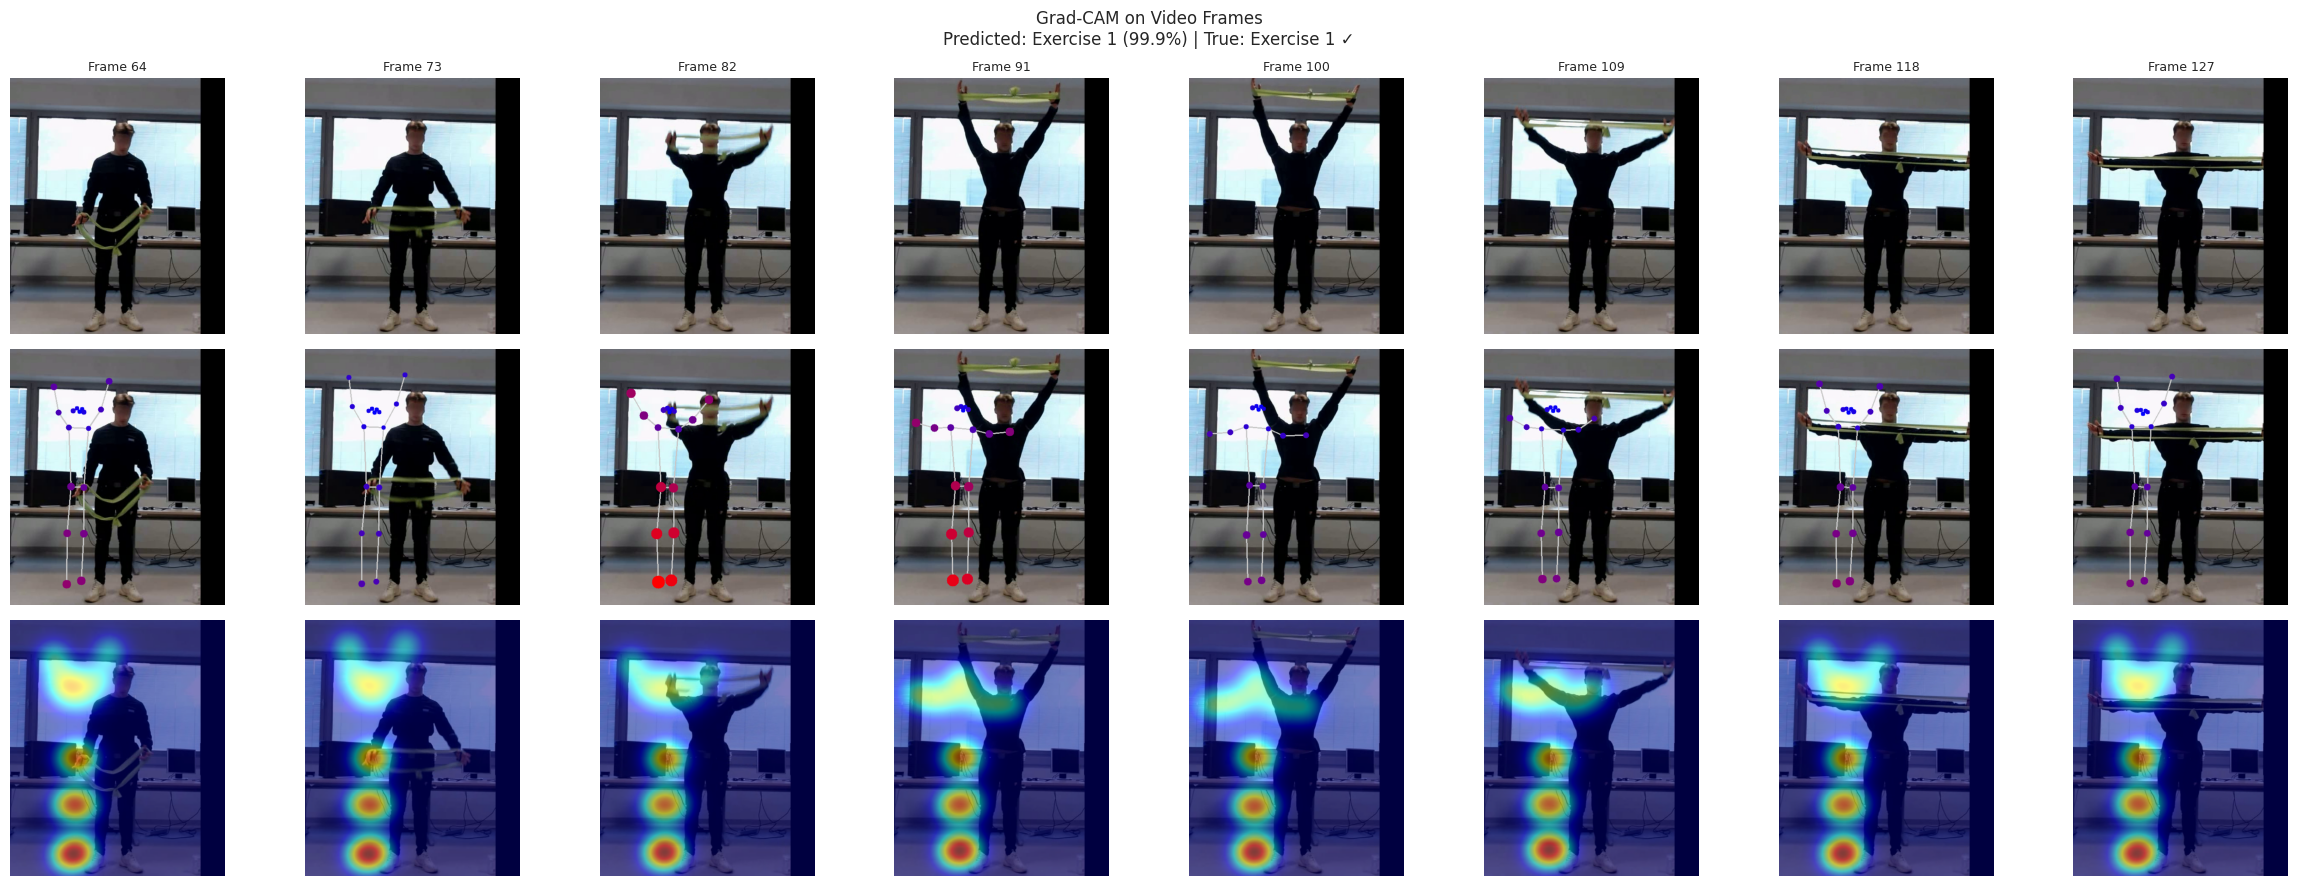

  Saved to: /net/afscra/people/plgmateuszoracz/wk/project/output/gradcam_video_034_sf5d2me1.png

Sample 2/5: 010_cxi86td1
  True class: Exercise 1
  Predicted: Exercise 8 (30.8%)
  Correct: ✗


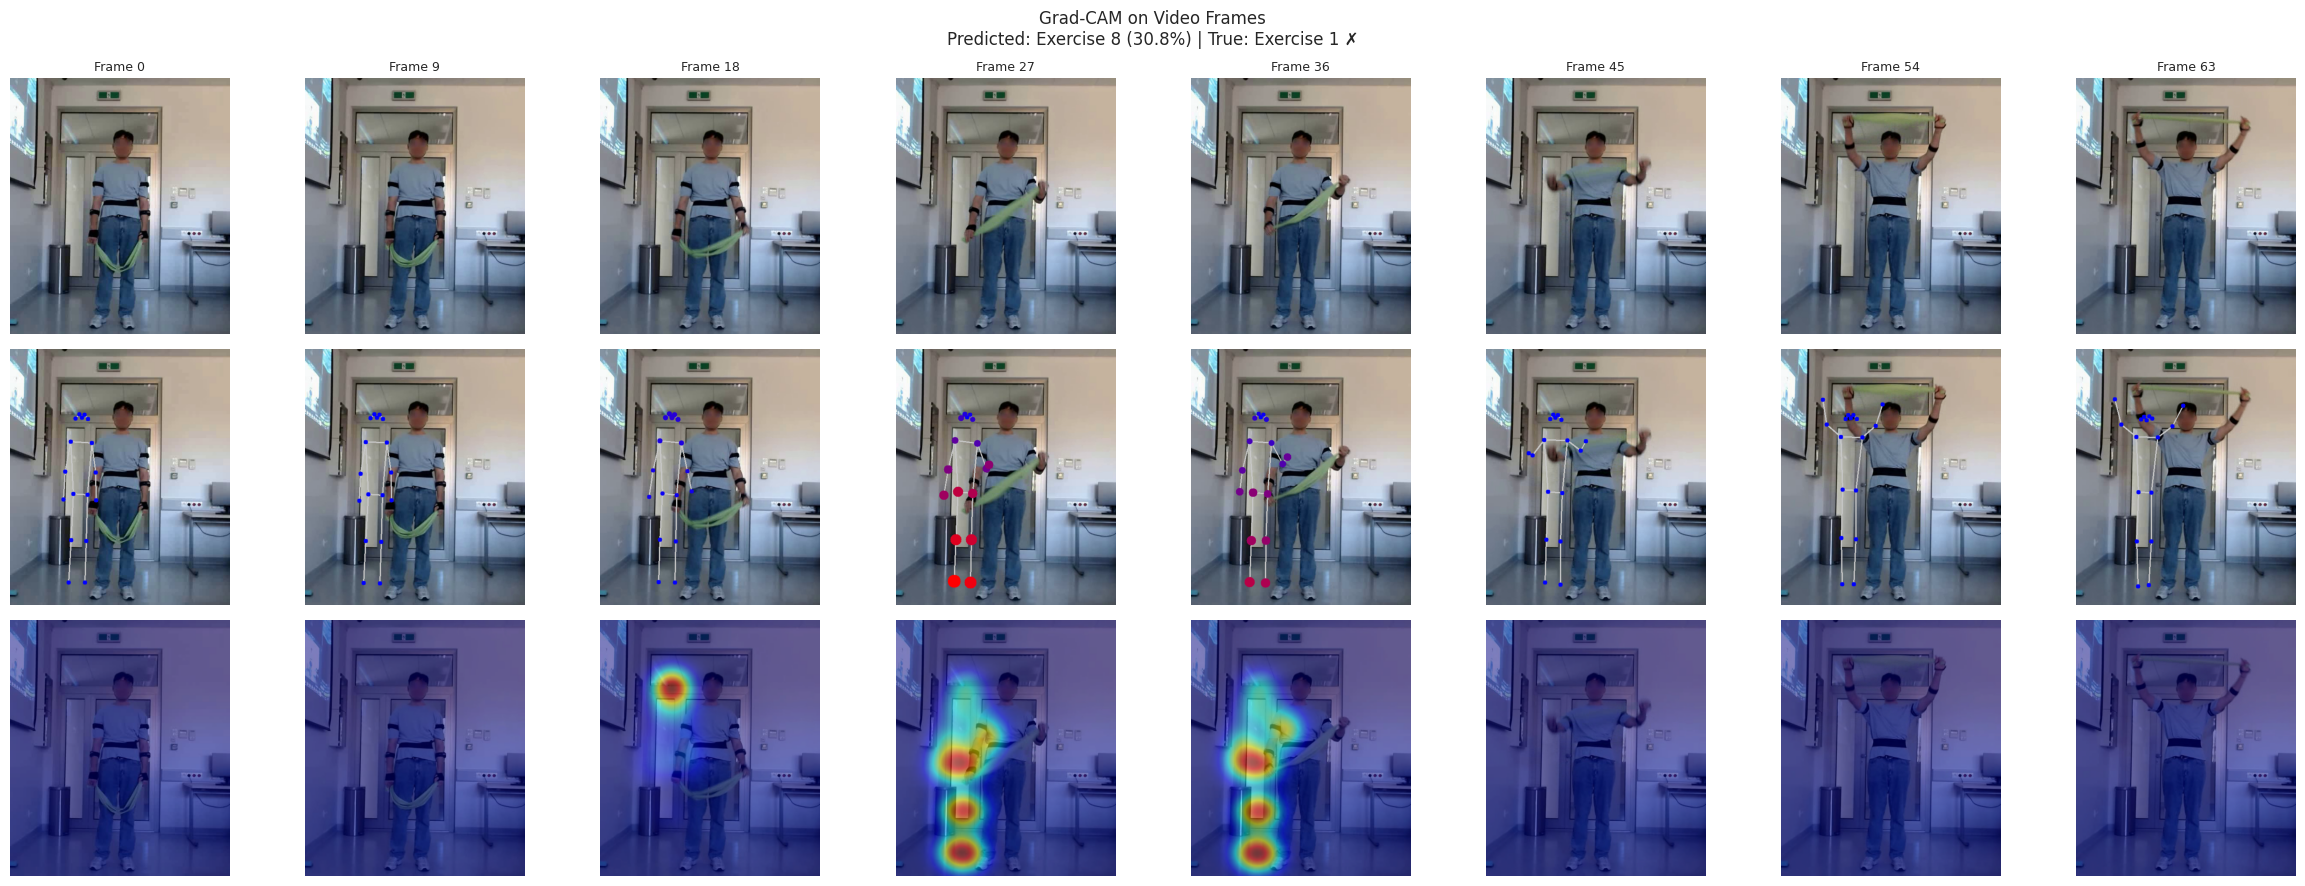

  Saved to: /net/afscra/people/plgmateuszoracz/wk/project/output/gradcam_video_010_cxi86td1.png

Sample 3/5: 041_i0whlre1
  True class: Exercise 1
  Predicted: Exercise 1 (99.7%)
  Correct: ✓


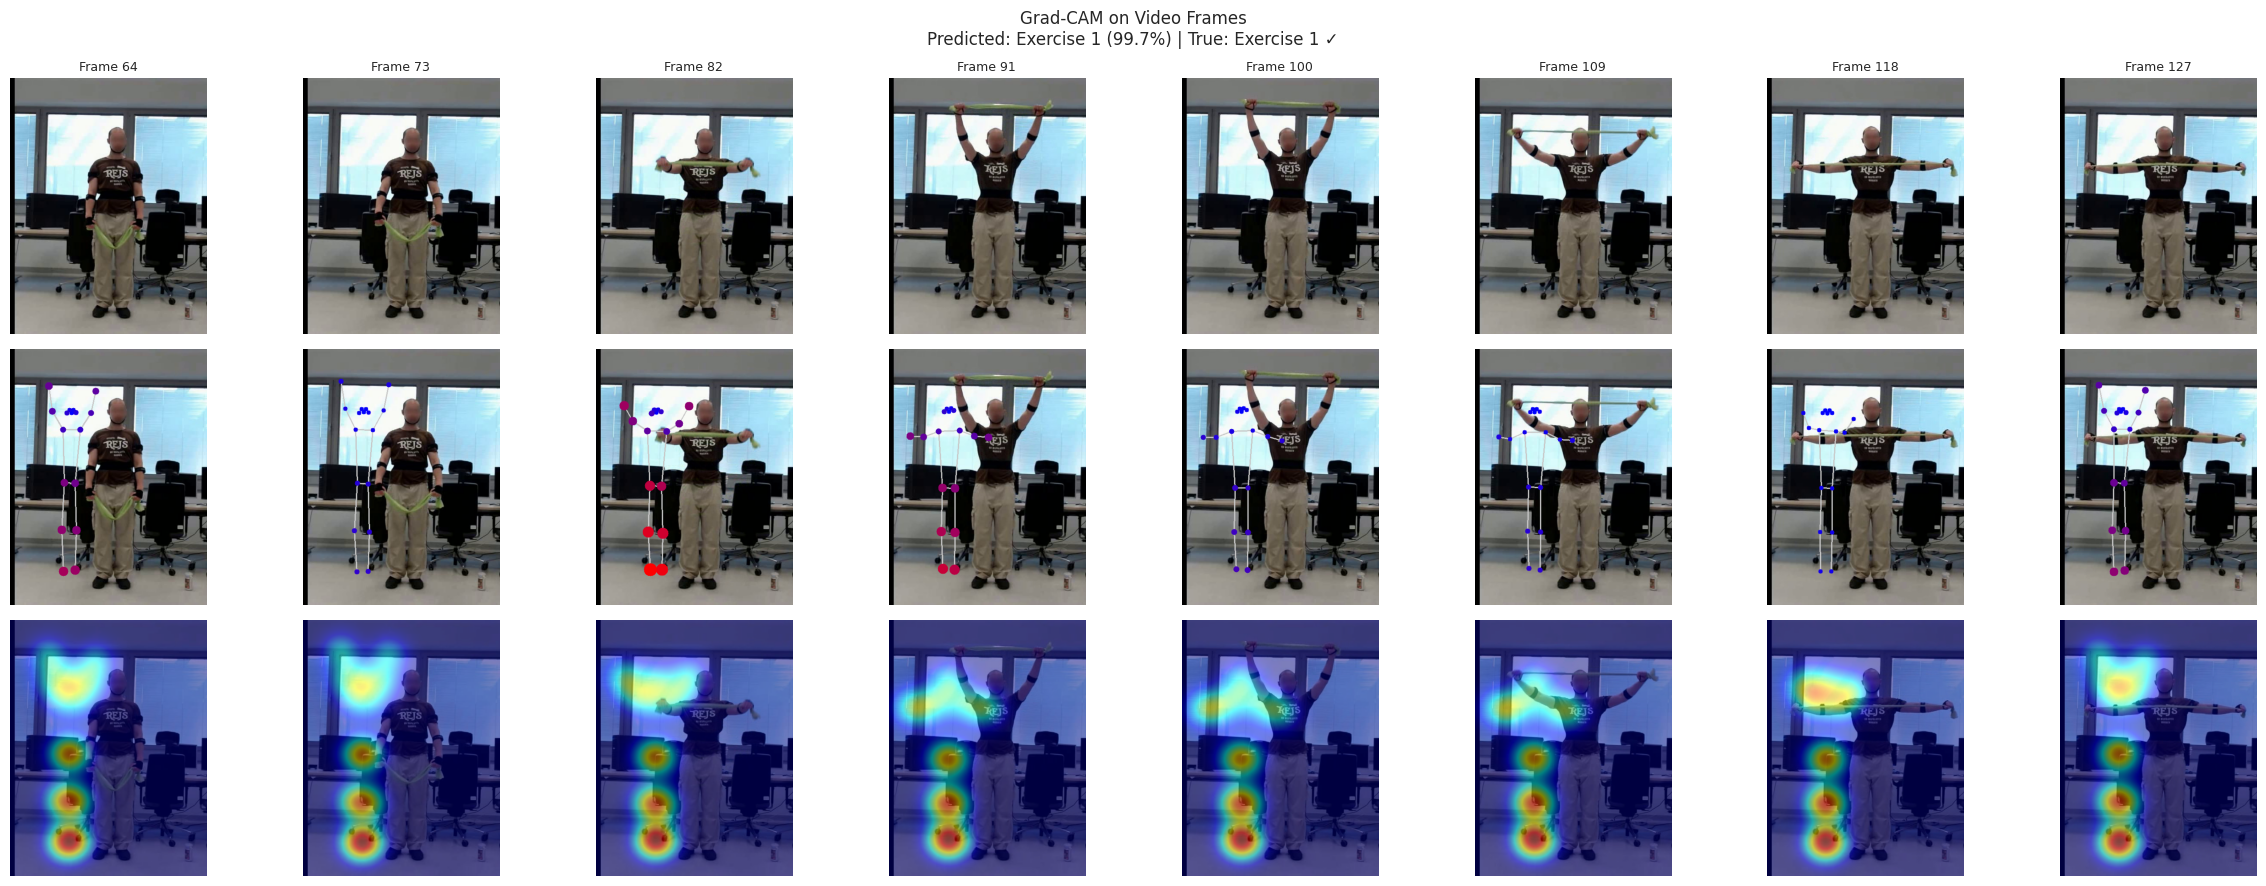

  Saved to: /net/afscra/people/plgmateuszoracz/wk/project/output/gradcam_video_041_i0whlre1.png

Sample 4/5: 040_z7beiye1_
  True class: Exercise 1
  Predicted: Exercise 1 (99.8%)
  Correct: ✓


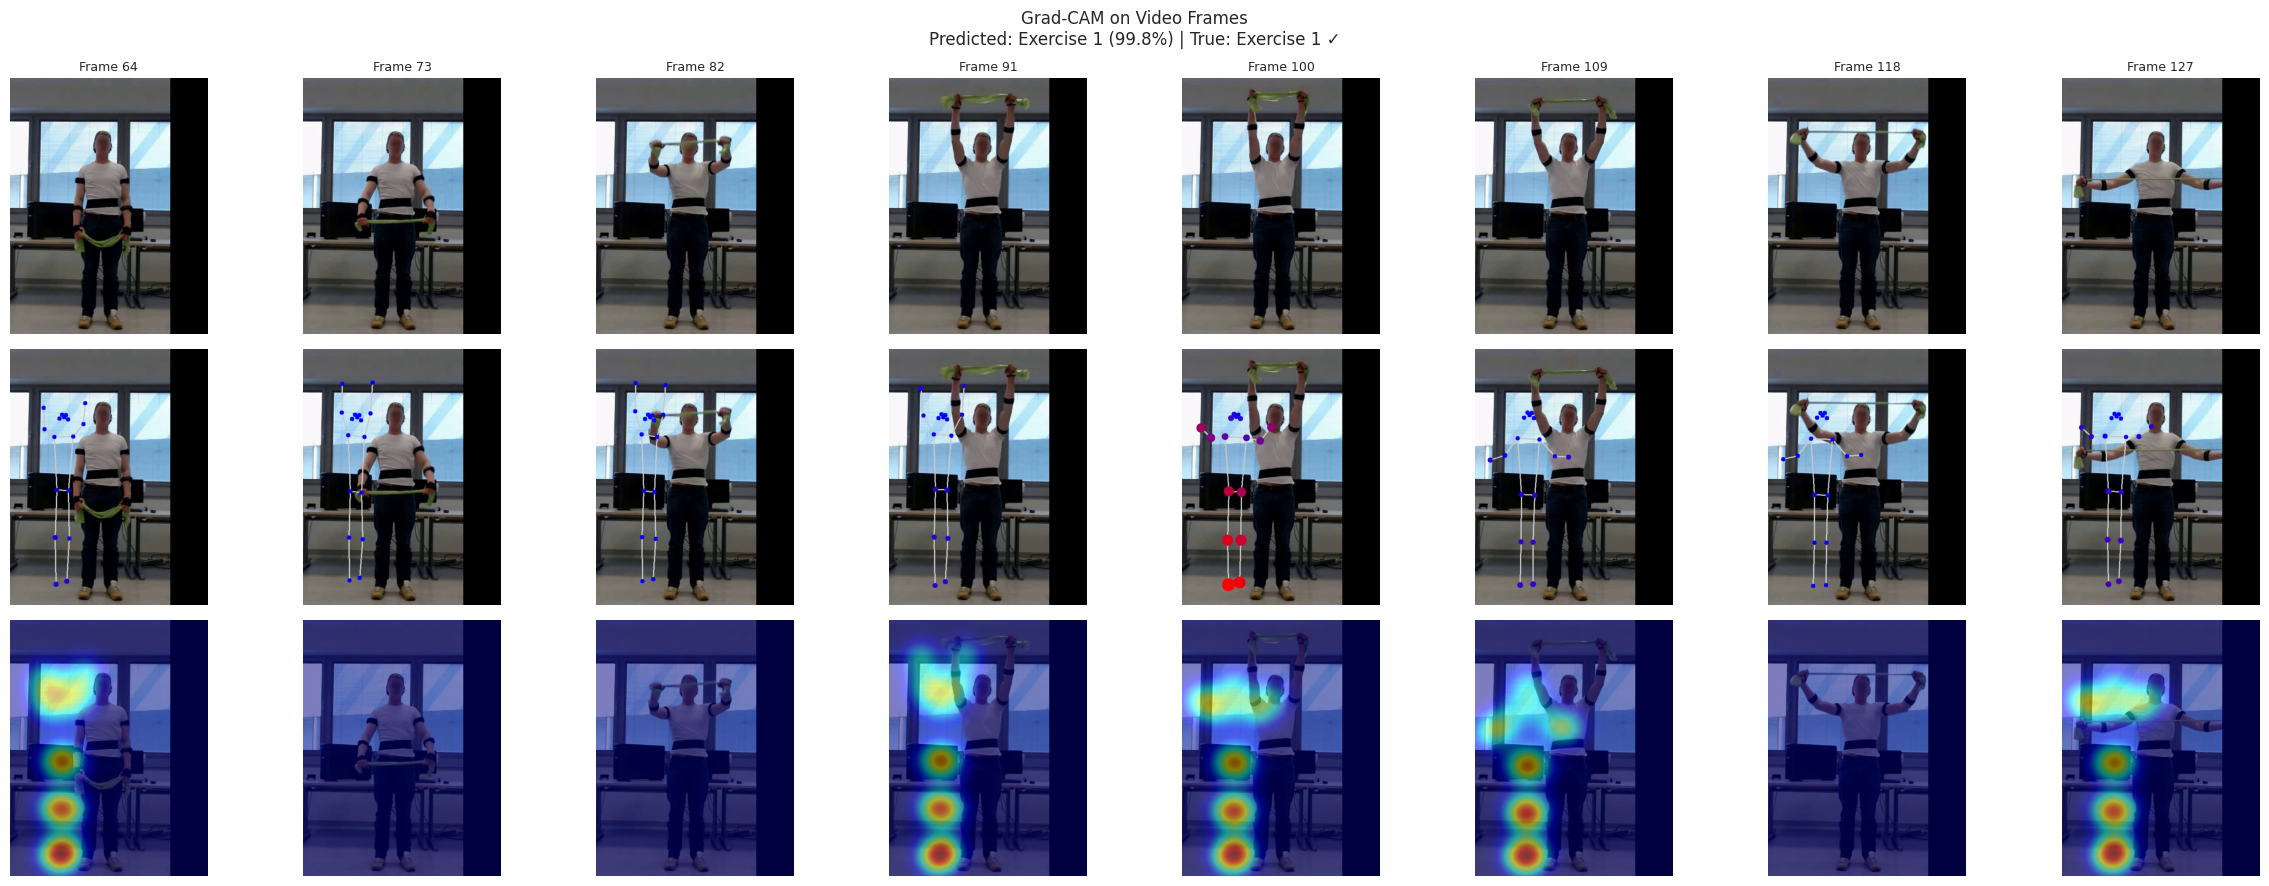

  Saved to: /net/afscra/people/plgmateuszoracz/wk/project/output/gradcam_video_040_z7beiye1_.png

Sample 5/5: 036_froktoe1
  True class: Exercise 1
  Predicted: Exercise 1 (83.5%)
  Correct: ✓


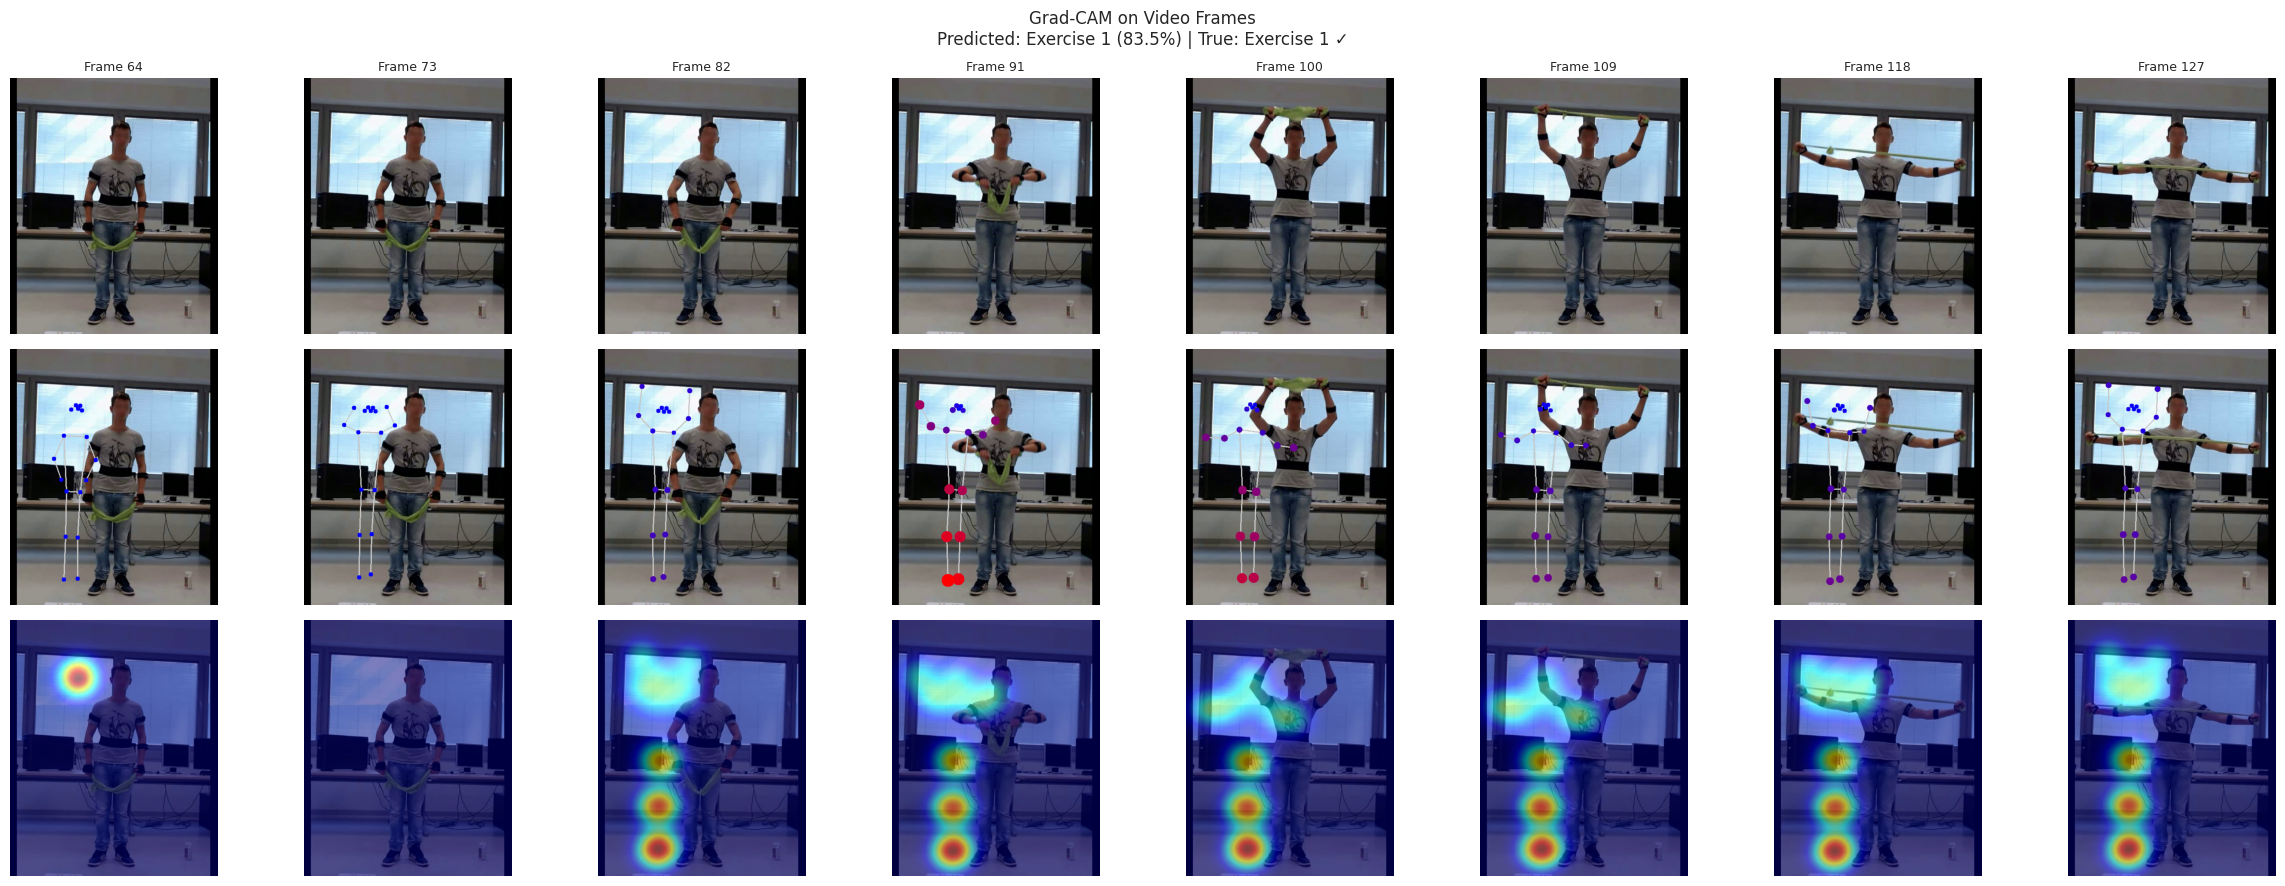

  Saved to: /net/afscra/people/plgmateuszoracz/wk/project/output/gradcam_video_036_froktoe1.png


In [28]:
# Initialize Grad-CAM
gradcam = GradCAM(model, target_layer_idx=-1)

# Generate visualizations
num_samples = min(5, len(test_samples_with_video))

for i, sample in enumerate(test_samples_with_video[:num_samples]):
    print(f"\n{'='*60}")
    print(f"Sample {i+1}/{num_samples}: {sample['file_name']}")
    print(f"{'='*60}")
    
    # Prepare input
    seq_data = sample['skeleton_data'].copy()
    seq_data = seq_data.transpose(2, 0, 1)  # (3, T, K)
    input_tensor = torch.FloatTensor(seq_data).unsqueeze(0).to(device)
    
    # Generate Grad-CAM
    cam, pred_class, pred_prob = gradcam.generate_cam(input_tensor)
    
    print(f"  True class: Exercise {sample['true_label']}")
    print(f"  Predicted: Exercise {idx_to_label[pred_class]} ({pred_prob:.1%})")
    print(f"  Correct: {'✓' if pred_class == sample['true_class'] else '✗'}")
    
    # Visualize
    save_path = OUTPUT_DIR / f"gradcam_video_{sample['file_name']}.png"
    
    visualize_gradcam_on_video(
        video_path=sample['video_path'],
        skeleton_data=seq_data,
        cam=cam,
        start_frame=sample['start_frame'],
        pred_class=pred_class,
        true_class=sample['true_class'],
        pred_prob=pred_prob,
        idx_to_label=idx_to_label,
        num_frames_to_show=8,
        save_path=save_path
    )
    
    print(f"  Saved to: {save_path}")

In [29]:
# Cleanup
gradcam.remove_hooks()
print(f"\nAll video Grad-CAM visualizations saved to: {OUTPUT_DIR}")


All video Grad-CAM visualizations saved to: /net/afscra/people/plgmateuszoracz/wk/project/output
